# Simulations

This purpose of this notebook is to generate Smatrices for components. The Smatrices are dictionaries to be used by sax, with keys format ("in0","out0")

Here the geometries of the components are optimized and simulated

## Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

import gdsfactory as gf

import tidy3d as td
import tidy3d.web as web
from tidy3d.plugins.mode import ModeSolver
from tidy3d.plugins.dispersion import AdvancedFastFitterParam, FastDispersionFitter

import gplugins as gp
import gplugins.tidy3d as gt
from gplugins import plot
from gplugins.common.config import PATH

import sax

import pickle

import mylibrary as my

from cspdk.si220.cband import cells, PDK, LAYER_STACK
PDK.activate()

## Loading Material Data

Since I am using the Cornerstone pdk, need to load the material data provided by the Cornerstone Design Guidelines from measured experimental values.
[link 1](https://www.cornerstone.sotonfab.co.uk/wp-content/uploads/2025/04/CORNERSTONE-45th-Call-Design-Guidelines.pdf?)
[link 2](https://cornerstone.sotonfab.co.uk/mpw/live-calls/)

First we load the data from the csv file. wavelngth units need to be in $\mu m$

In [2]:
fname = "Si_SiO2_refractive_index-3.csv"

wvs = np.loadtxt(fname,skiprows=1,usecols=0,delimiter=',',max_rows=30)*1e-3
n_sio2 = np.loadtxt(fname,skiprows=1,usecols=1,delimiter=',',max_rows=30)
n_si = np.loadtxt(fname,skiprows=1,usecols=2,delimiter=',',max_rows=30)
k = np.zeros(30)


We need to fit a model for the medium from the discrete experimental data points for both Si and SiO2. Done using tidy3d provided function which creates the ready to use medium object.

Output()

10:14:33 CEST WARNING: Unable to fit with weighted RMS error under              
              'tolerance_rms' of 1e-05                                          

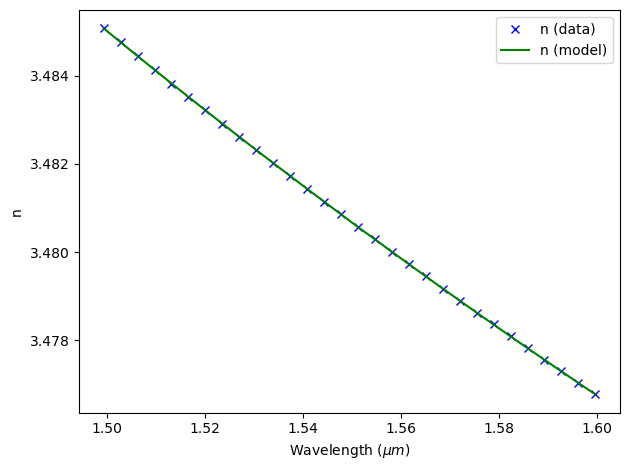

In [3]:
fitter = FastDispersionFitter(wvl_um=wvs, n_data=n_si,k_data=k)
advanced_param = AdvancedFastFitterParam(weights=(1, 1))
medium_si, rms_error = fitter.fit(max_num_poles=2, advanced_param=advanced_param)#, tolerance_rms=2e-2)
fitter.plot(medium_si)
plt.show()


Output()

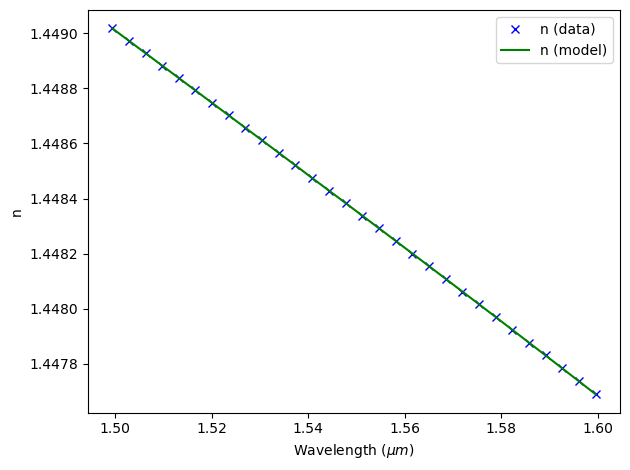

In [4]:
fitter = FastDispersionFitter(wvl_um=wvs, n_data=n_sio2,k_data=k)
advanced_param = AdvancedFastFitterParam(weights=(1, 1))
medium_sio2, rms_error = fitter.fit(max_num_poles=3, advanced_param=advanced_param)#, tolerance_rms=2e-2)
fitter.plot(medium_sio2)
plt.show()


As explained later, the fdtd simulations are not stable with a dispersive medium, and I only care about one wavelength $1.55\mu m$ in this project so I define constant index mediums at the desired wavelength

In [5]:
wavelength = 1.55
freq = td.C_0 / wavelength

eps_si = medium_si.eps_model(freq)
n_si = np.sqrt(eps_si)
eps_sio2 = medium_sio2.eps_model(freq)
n_sio2 = np.sqrt(eps_sio2)
#imaginary part is numerical error (not provided by conerstone) so i drop it in the models
medium_si_1550 = td.Medium(permittivity=float(np.real(eps_si)))
medium_sio2_1550 = td.Medium(permittivity=float(np.real(eps_sio2)))

print("epsilon:", eps_si)
print("n:", n_si)

print("epsilon:", eps_sio2)
print("n:", n_sio2)

epsilon: (12.115048974728925+1.4825357068223094e-13j)
n: (3.4806678920472898+2.12967130562735e-14j)
epsilon: (2.0977284722234613+1.9667996419025953e-14j)
n: (1.4483537110193287+6.7897766510308884e-15j)


## Functions

### beat_length_coupler(component, layerstack, mapping, clad_medium, wavelength)
returns the analytical beat length of a coupler's coupling region and the effective indices of the even and odd TE supermodes. requires the coupler to be symmetric and light propation direction is along x
Runs using tidy3d library but locally, not on cloud

In [ ]:
def beat_length_coupler(component, layerstack, mapping, wavelength=1.55):

    c = gt.Tidy3DComponent(
        component=component,
        layer_stack=layerstack,
        material_mapping=mapping,
        pad_xy_inner=0.5,
        pad_xy_outer=0.1,
        pad_z_inner=0,
        pad_z_outer=0,
        extend_ports=0.3,
    )

    modeler = c.get_component_modeler(
        center_z="core",
        port_size_mult=(6, 4),
        sim_size_z=3.0,
        medium=mapping['sio2'],
    )

    sim = modeler.simulation

    # center of original gdsfactory geometry
    bbox = component.bbox()
    x_mid = (bbox.left + bbox.right) / 2

    plane = td.Box(
        center=(x_mid, 0, c.get_layer_center("core")[2]),
        size=(0, td.inf, td.inf),
    )

    mode_solver = ModeSolver(
        simulation=sim,
        plane=plane,
        mode_spec=td.ModeSpec(
            num_modes=2,
            target_neff=3.4,
        ),
        freqs=[td.C_0 / wavelength],
    )

    mode_data = mode_solver.solve()
    n1 = mode_data.n_eff.values[0,0]
    n2 = mode_data.n_eff.values[0,1]
    neff = mode_data.n_eff.values

    beat_length = wavelength/(2*abs(n1 - n2))

    return beat_length, neff

## Phase Calibration

We need a consistent phase model to be able to conduct whole circuit S-parameter simulations.
In order for FDTD simulations to run correctly, they require the simulation ports and monitors to be distant from the boundaries of components, this is done by extending and offsetting potrs.
But this adds a consisten phase offest to the final Smatrix which needs to be accounted for. All my simulations use the same simulation settings and port extensions, hence the extra fdtd phase shift is consistent across all component simulations. This extra phase reference offset is calculated in the following section and used for calibrating all component Smatrices.

We find the numerical effective index and the fdtd phase offset by running a sweep of fdtd simulation of the waveguide legnths from 1 to 10 $\mu m$. Keeping all the simulation settings identical (for the entire project the simulation settings are identical). We save the final phase at the output port into a list called phase.

In [11]:
lengths = np.linspace(1, 10, 10)

phase = []

for length in lengths:
    component = cells.straight(length=length)

    filepath = (Path.home()/ "tidy3d_results"/f"straight_45_L{length:.2f}.npz")

    sp = gt.write_sparameters(
        component=component,
        filepath=filepath,
        **component_settings,
        **simulation_settings,    
    )

    phase_ = np.angle(sp['o1@0,o2@0'])
    phase.append(phase_)

Simulation loaded from PosixPath('/Users/cadmus/tidy3d_results/straight_45_L1.00.npz')
Simulation loaded from PosixPath('/Users/cadmus/tidy3d_results/straight_45_L2.00.npz')
Simulation loaded from PosixPath('/Users/cadmus/tidy3d_results/straight_45_L3.00.npz')
Simulation loaded from PosixPath('/Users/cadmus/tidy3d_results/straight_45_L4.00.npz')
Simulation loaded from PosixPath('/Users/cadmus/tidy3d_results/straight_45_L5.00.npz')
Simulation loaded from PosixPath('/Users/cadmus/tidy3d_results/straight_45_L6.00.npz')
Simulation loaded from PosixPath('/Users/cadmus/tidy3d_results/straight_45_L7.00.npz')
Simulation loaded from PosixPath('/Users/cadmus/tidy3d_results/straight_45_L8.00.npz')
Simulation loaded from PosixPath('/Users/cadmus/tidy3d_results/straight_45_L9.00.npz')
Simulation loaded from PosixPath('/Users/cadmus/tidy3d_results/straight_45_L10.00.npz')


The phases saved in the sweep are all between $[-\pi, \pi]$. But to compare them over the waveguide length we need the full phase evolution, not the modulo $2\pi$. To get this we compare the phases of adjacent simulations (separated by $1\mu m$ length), and find how many multiples of $2\pi$ exist between the two points and then add that many multiples to get the phase in terms of absolute units. This is plotted with a best fit line 

fdtd n_eff [2.29081988]
Extra Phase [-0.81279941]


Text(0, 0.5, 'total phase accumulation (rad)')

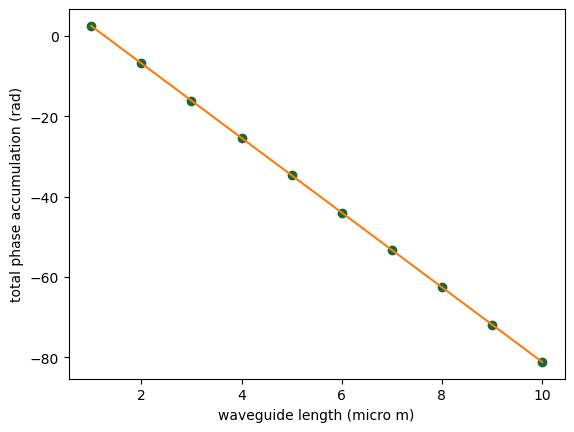

In [12]:
bigger_lengths=np.linspace(1,10,40)
phase_wrapped = np.asarray(phase)
phase_unwrapped = phase_wrapped.copy()

beta_est = 2*np.pi*2.3646/1.55
for i in range(1, 10):
    phase_diff = phase_unwrapped[i-1] - beta_est*1 
    m = np.round((phase_diff - phase_wrapped[i])/(2*np.pi)) 
    phase_unwrapped[i] = phase_wrapped[i] + 2*np.pi*m

slope, phi_port = np.polyfit(lengths, phase_unwrapped, 1)

beta_fdtd = -slope
neff_fdtd = beta_fdtd*1.55/(2*np.pi)
print("fdtd n_eff",neff_fdtd)
print("Extra Phase", np.angle(np.exp(1j*phi_port)))
plt.plot(lengths, phase_unwrapped, "o")
plt.plot(bigger_lengths, bigger_lengths*slope+phi_port)
plt.xlabel("waveguide length (micro m)")
plt.ylabel("total phase accumulation (rad)")

Based on this graph we find that the effective index from the fdtd simluations is $n_{eff}=2.2908$.

The simulations show a phase offset of $-0.8128 rad$. This is the offset from the simulation settings. This offset will be used to calibrate the Smatrices from all the FDTD simulations for all components.

To test the calibration we compare the phase evolution from fdtd simluations of a waveguide lengths $20\mu m$ with multiple smaller waveguides connected together with lengths adding up to 20. Waveguides lengths: $2\mu m + 3\mu m+ 5\mu m+ 10\mu m = 20\mu m$

(Simulation of waveguide length $20\mu m$ previously run and saved in same folder)

All the Smatrices of the waveguides are first calibrated for the phase offset found above. The calibration is done by subtracting the phase offset - by dividing by the factor A:

In [13]:
A=np.exp(1j*phi_port)

In [14]:
sp5 = np.load(Path.home()/ "tidy3d_results"/"straight_45_L5.00.npz")
cal_5 = sp5["o1@0,o2@0"]/A
sp10 = np.load(Path.home()/ "tidy3d_results"/"straight_45_L10.00.npz")
cal_10 = sp10["o1@0,o2@0"]/A
sp2 = np.load(Path.home()/ "tidy3d_results"/"straight_45_L2.00.npz")
cal_2 = sp2["o1@0,o2@0"]/A
sp3 = np.load(Path.home()/ "tidy3d_results"/"straight_45_L3.00.npz")
cal_3 = sp3["o1@0,o2@0"]/A
sp20 = np.load(Path.home()/ "tidy3d_results"/"straight_L20.00.npz")
cal_20 = sp20["o1@0,o2@0"]/A

def matrix_2():
    return sax.reciprocal({("in0", "out0"): cal_2})
def matrix_3():
    return sax.reciprocal({("in0", "out0"): cal_3})
def matrix_5():
    return sax.reciprocal({("in0", "out0"): cal_5})
def matrix_10():
    return sax.reciprocal({("in0", "out0"): cal_10})
matrix_20 = sax.reciprocal({("in0", "out0"): cal_20})

test_circuit, info = sax.circuit(
    netlist={
        "instances": {
            "w2": "waveguide2",
            "w3": "waveguide3",
            "w5": "waveguide5",
            "w10": "waveguide10",
        },
        "connections": {
            "w2,out0": "w3,in0",
            "w3,out0": "w5,in0",
            "w5,out0": "w10,in0",
        },
        "ports": {
            "in0": "w2,in0",
            "out0": "w10,out0",
        },
    },
    models={
        "waveguide2": matrix_2,
        "waveguide3": matrix_3,
        "waveguide5": matrix_5,
        "waveguide10": matrix_10,
    },
)

result = test_circuit()
print('magnitude error', abs(abs(result[('in0','out0')])-abs(matrix_20[('in0','out0')]))[0]*100, "%")
print('phase error', np.angle(result[('in0','out0')][0]/matrix_20[('in0','out0')][0], deg=True), "deg")

magnitude error 0.5446874349341102 %
phase error -0.0570512709200215 deg


As we can see the total phase after connecting waveguides is the same as that of one long waveguide to 0.06 degree. This is a high and sufficient level of accuracy. Hence the calibration works and we can use these results for other circuit simulations. We do this to have consistent phase reference and accumulation accross components, so that circuit simulations are effective.

### Save Waveguide Sax Dict
We also need to save the waveguide deafult length 10 into a sax dictionary for later use in the mesh

In [15]:
filepath = Path.home() / "tidy3d_results" / "straight_45_L10.00.npz"
wvgd_tidy = np.load(filepath)

wvgd_dict=sax.reciprocal({
    ("in0", "out0"): wvgd_tidy["o1@0,o2@0"]/A
})
filepath = Path.home() / "sax_models" / "straight_L10.pkl"
with filepath.open("wb") as f:
    pickle.dump(wvgd_dict, f)

## Optimizing Coupler
I am using the coupler from the Cornerstone Si 220 Cband PDK. This Coupler is symmetric but simulations show that it is not a 50/50 coupler. The design of the mesh interferrometer requires a symmetric 50/50 coupler, hence the PDK coupler gap and length are tuned to optimize the spliting.

###### ------------------------------------------------------------------------------------------------
### Estimating Coupler parameters
The first step in optimizing coupler is calculating the beating length in the coupling region from the supermodes. The simulations use the medium material indices from Cornerstone [Loading Material Data](#Loading-Material-Data)

The coupler has defualt coupling length $14.5\mu m$ and gap $0.27 \mu m$.\
Using tidy3D mode solver we find the supermodes of the coupler

In [ ]:
component = cells.coupler()

#mapping takes a medium object, can define from td.Medium(permittivity=n_si**2), td.material_library["SiO2"].medium, or the previous fitting function
mapping = {
    "si": medium_si,
    "sio2": medium_sio2,
}

c = gt.Tidy3DComponent(
    component=component,
    layer_stack=LAYER_STACK,
    material_mapping=mapping,
    pad_xy_inner=0.5,
    pad_xy_outer=0.1,
    pad_z_inner=0,
    pad_z_outer=0,
    extend_ports=0.3,
)
# Build the Tidy3D simulation geometry from your GDSFactory component
modeler = c.get_component_modeler(
    center_z="core",
    port_size_mult=(6, 4),
    sim_size_z=3.0,
    medium = medium_sio2
)

sim = modeler.simulation

# YZ plane at x = 7 um
plane = td.Box(
    center=(7, 0, c.get_layer_center("core")[2]),
    size=(0, td.inf, td.inf),
)

mode_solver = ModeSolver(
    simulation=sim,
    plane=plane,
    mode_spec=td.ModeSpec(num_modes=4, target_neff=3.4),
    freqs=[td.C_0 / 1.55],
)

#  eigenmode solver
#mode_data = mode_solver.solve()
#print(mode_data.n_eff.values)

only plotting first two modes because they are the fundamental supermode. The eigenmodes are TE can prove. 

(<Figure size 427.875x600 with 4 Axes>,
 array([[<Axes: title={'center': 'Ey, mode_index=0\nn_eff=2.42'}, xlabel='y (μm)', ylabel='z (μm)'>],
        [<Axes: title={'center': 'Ey, mode_index=1\nn_eff=2.404'}, xlabel='y (μm)', ylabel='z (μm)'>]],
       dtype=object))

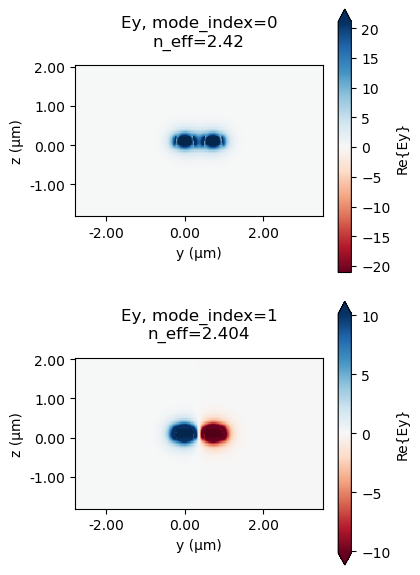

In [29]:
mode_solver.plot_field_components(
    ["Ey"],
    mode_indices=[0, 1],
    val="real",
    show_n_eff=True,
)

The fundamental supermodes are TE modes. \
We call function beat_length_coupler which automatically returns the beat length and the effective indices of the supermodes, defined in [Functions](#Functions) \
From the effective refractive index difference bewtween the even and odd modes we find the analytical Beating length which is the the length of the coupling region which produces 100% power crossover from one waveguide into the other. The formula for this beating or cross-over length is $$\frac{\lambda}{2\times (n_{eff, even} - n_{eff, odd})}$$ \
The effective indices of the modes are:

In [30]:
Lbeat, neff = beat_length_coupler(component, LAYER_STACK, mapping, sio2)
print("neff:", neff)

neff: [[2.41979592 2.40386942]]


And the beating length is 

In [47]:
print("Beat length:", Lbeat, "\u03BCm")
print("50% coupling length", Lbeat/2,"\u03BCm")

Beat length: 43.06100546259323 μm
50% coupling length 21.530502731296615 μm


However the actual coupler structure is composed of two distant waveguides that bend towards each other into a copuling region and then bend back away for the output as shown below. This means that a realistic 50/50 splitter will have a coupling region with length smaller than $21.5\mu m$.

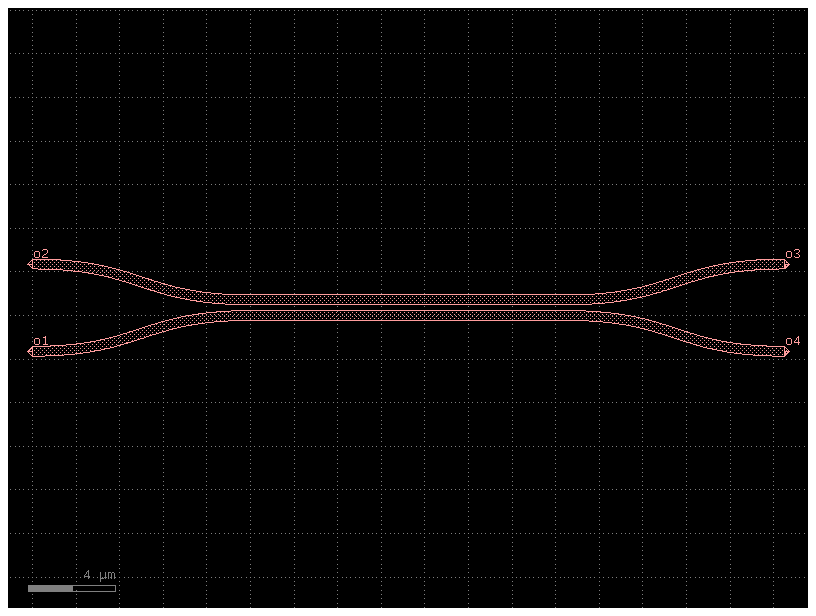

In [50]:
component.draw_ports()
component.plot()

Because the coupling between waveguides begins before the copuling region in the bending section as soon as the waveguides are close enough to each other. So the actual coupling region for the full coupler is shorter than the analytical $21.5\mu m$. \
To simulate the full coupler we use FDTD which calculates EM field propagation through the entire geometry of the coupler. The main difficulty with FDTD is that it is computationally expensive, especially when running a 3D simulation. The Meep open source package is a useful and convenient library to run FDTD, but on small personal hardware 3D simulations are completely impractical. However Meep is useful for 2D FDTD for quick benchmarking and small simulations.

For complete 3D FDTD I use tidy3d which offers gpu accelerated cloud computations with a python API. tidy3d completes large simulations in minutes and is very convenient in terms of python scripting and compatitbility with gdsfactory. gdsfactory plugins offer functions that automate conversion between gds layout and tidy3d geometries, easy simulation and Sparameter extraction. All the simulations and testing done here uses the material source data from tidy3D material library. 

3D simulations of the default PDK coupler show that the coupler is not a perfect 50/50 splitter, the split ration is around 40%, with 60% of the light remaining in the initial excited waveguide.


In order to obtain the desider perfect power splitting we need to increase the coupling. One option is to increase the length of the coupling region, however minimizing the footprint of components is much preferred for reasons of loss reduction, fabrication efficiency and noise 
reduction. The other option is to decrease the gap between coupling waveguides, of course this needs to conform to DRC and fabrication tolerances.

The following script test the analytical coupling length when the gap between waveguides is reduced from the default 0.27 $\mu m$ to $0.25 \mu m$.

We call function beat_length_coupler which automatically returns the beat length and the effective indices of the supermodes, defined in [Functions](#Functions)

In [51]:
component = cells.coupler(gap=0.25)
Lbeat, neff = beat_length_coupler(component, LAYER_STACK, mapping)
print("neff:", neff)
print("Beat length:", Lbeat, "\u03BCm")
print("50% coupling length", Lbeat/2,"\u03BCm")

neff: [[2.3676243  2.34626361]]
Beat length: 36.28160180216505 μm
50% coupling length 18.140800901082525 μm


With this smaller gap the coupling length is closer to the pdk coupler's default coupler length of $14.5 \mu m$, and there is more power crossover between the waveguides.

At this point we begin running fdtd simulations. Testing different parameters shows that when the coupling length is $15\mu m$ and the coupling gap is $0.25\mu m$, the coupler is almost a perfect 50/50 splitter.

The following uses gplugins to create Tidy3D components from the gds component with padding and extensions for the simulation volume.

The fdtd code in the cell below requires requires defining the component settings (which include padding region and extending ports) and simulation settings which define the fdtd simulation. Since the geometry of the coupler is symmetric, we only need to simulate excitations from one input port, this reduces the computation required by 4 times.

Then we run the write_sparamters function which returns the Sparameters following a full FDTD simualtion and saves the data to a local file in folder I called tidy3d_results. Each simulation run should have unique name. Running the same simulation name will load the previously saved data. This  Sparameter data is then accessed by other scripts to use for sparameter simulations.

Simulation note:
    -The cladding and core mediums we have defined from the Cornerstone data is dispersive. This was causing the simulation to diverge at high resultions- narrowed it to this issue. Dispersive media causing divergence is a known issue with tidy3d
    Since I am only evaluating everything at 1.55 $\mu m$, i only care about that frequency, so I redefine the mediums with constant index (no dispersion) for this part of the project.

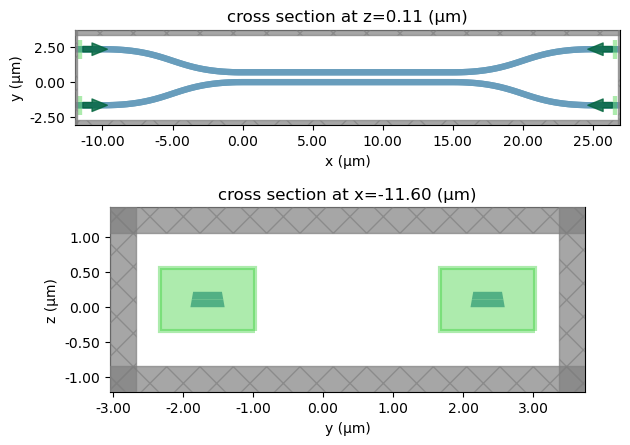

In [ ]:
component=cells.coupler(gap=0.25, length=15)

mapping = {
    "si": medium_si_1550,
    "sio2": medium_sio2_1550,
}

component_settings = dict(
    layer_stack=LAYER_STACK,
    material_mapping=mapping,
    pad_xy_inner=0.8,
    pad_xy_outer=1,
    pad_z_inner=0,
    pad_z_outer=0,
    extend_ports=1.0,
)

simulation_settings = dict(
    run_only=(("o1", 0),),
    center_z="core",
    sim_size_z=1.9,
    medium=medium_sio2_1550,
    port_size_mult=(3, 2),
    wavelength=1.55,
    bandwidth=0,
    num_freqs=1,
    min_steps_per_wvl=35,
    run_time=3e-12,
)

td_component = gt.Tidy3DComponent(
    component=component,
    **component_settings,
)

modeler = td_component.get_component_modeler(
    **simulation_settings,
)

fig, ax = plt.subplots(2, 1)
modeler.plot_sim(z=td_component.get_layer_center("core")[2], ax=ax[0])
modeler.plot_sim(x=td_component.ports[0].dcenter[0], ax=ax[1])
fig.tight_layout()
plt.show()

can estimate cost of simulation by uploading to server but not running

In [115]:
task_id = web.upload(modeler)

14:29:58 CEST Created task 'modal_cm_2026-07-29_14-29-57' with resource_id      
              'sid-843c1c28-111f-47d4-8361-2948d7dc47de' and task_type          
              'MODAL_CM'.

Output()

14:30:08 CEST Maximum FlexCredit cost: 4.433. Minimum cost depends on task      
              execution details. Use 'web.real_cost(task_id)' after run.

Now we run a proper simulation

In [ ]:
filepath = (Path.home() / "tidy3d_results" / "coupler2_3d_gap0.25_15_nondisp2_finer3_bigger2.npz") #complicated name after much trial and error
filepath.parent.mkdir(parents=True, exist_ok=True)

sp = gt.write_sparameters(
    component=component,
    filepath=filepath,
    **component_settings,
    **simulation_settings,
)

16:46:22 CEST Created task '5c7600d3bcd0ff741a214cbdc9cdc946' with resource_id  
              'sid-af4f1b23-69ca-45c4-96eb-a618d98c4ddd' and task_type          
              'MODAL_CM'.

Output()

16:46:32 CEST Maximum FlexCredit cost: 4.846. Minimum cost depends on task      
              execution details. Use 'web.real_cost(task_id)' after run.

16:46:34 CEST Subtasks status - 5c7600d3bcd0ff741a214cbdc9cdc946                
              Group ID: 'pa-e0ccc837-6093-4ef5-a904-2a2a529c6166'

Output()

...

16:48:26 CEST Modeler has finished running successfully.

              Billed flex credit cost: 1.039.

Output()

16:48:29 CEST Loading results from                                              
              /Users/cadmus/.gdsfactory/sparameters/5c7600d3bcd0ff741a214cbdc9cd
              c946/simulation.hdf5

Simulation saved to PosixPath('/Users/cadmus/tidy3d_results/coupler2_3d_gap0.25_15_nondisp2_finer3_bigger2.npz')


In [69]:
through = np.abs(sp["o1@0,o4@0"])**2
cross   = np.abs(sp["o1@0,o3@0"])**2

print("Through power:", through)
print("Cross power:", cross)
print("Total:", through + cross)

Through power: [0.5040594]
Cross power: [0.49231133]
Total: [0.99637073]


i have proven convergence and almost found answer, now do a sweep

based on my finding it keeps local cache of the parameters even if i cahnge name it reloads same results.  but also caches name so different params, same name loads same results

###### ------------------------------------------------------------------------------------------------
### Length sweeps and iterative optimization

Now that we have an approximate idea of the coupling length required for 50/50 power split, we run a parameter sweep across the length range $14-16\mu m$. Iteratively the range is then decreased and the fdtd resolution increased to find the optimum length.

gdsfactory's gplugins has a tidy3d batch functionality 'gt.write_sparameters_grating_coupler_batch(jobs)' that automatically returns the normalized Smatrices - but when this script was written the documentation webpage was brooken, so I wrote it such that the paramters sweep calls the write_sparameters in a loop. Tidy3d has batch support, but I am using the gplugins functions because they automatically return a complete Smatrix


In [ ]:
lengths = np.linspace(14, 16, 11)

through = []
cross = []
total = []

mapping = {
    "si": medium_si_1550,
    "sio2": medium_sio2_1550,
}
simulation_settings = dict(
    run_only=(("o1", 0),),
    center_z="core",
    sim_size_z=1.9,
    medium=medium_sio2_1550,
    port_size_mult=(3, 2),
    wavelength=1.55,
    bandwidth=0,
    num_freqs=1,
    min_steps_per_wvl=25,
    run_time=3e-12,
)
component_settings = dict(
    layer_stack=LAYER_STACK,
    material_mapping=mapping,
    pad_xy_inner=0.8,
    pad_xy_outer=1,
    pad_z_inner=0,
    pad_z_outer=0,
    extend_ports=1.0,
)

for length in lengths:
    component = cells.coupler(gap=0.25, length=length)

    filepath = (Path.home()/ "tidy3d_results"/f"coupler_L{length:.2f}.npz")

    sp = gt.write_sparameters(
        component=component,
        filepath=filepath,
        **component_settings,
        **simulation_settings,    
    )

    p_through = np.abs(sp["o1@0,o4@0"])**2
    p_cross = np.abs(sp["o1@0,o3@0"])**2

    through.append(p_through)
    cross.append(p_cross)
    total.append(p_through + p_cross)

Simulation loaded from PosixPath('/Users/cadmus/tidy3d_results/coupler_L14.00.npz')
Simulation loaded from PosixPath('/Users/cadmus/tidy3d_results/coupler_L14.20.npz')
Simulation loaded from PosixPath('/Users/cadmus/tidy3d_results/coupler_L14.40.npz')
Simulation loaded from PosixPath('/Users/cadmus/tidy3d_results/coupler_L14.60.npz')
Simulation loaded from PosixPath('/Users/cadmus/tidy3d_results/coupler_L14.80.npz')
Simulation loaded from PosixPath('/Users/cadmus/tidy3d_results/coupler_L15.00.npz')
Simulation loaded from PosixPath('/Users/cadmus/tidy3d_results/coupler_L15.20.npz')
Simulation loaded from PosixPath('/Users/cadmus/tidy3d_results/coupler_L15.40.npz')
Simulation loaded from PosixPath('/Users/cadmus/tidy3d_results/coupler_L15.60.npz')
Simulation loaded from PosixPath('/Users/cadmus/tidy3d_results/coupler_L15.80.npz')
Simulation loaded from PosixPath('/Users/cadmus/tidy3d_results/coupler_L16.00.npz')


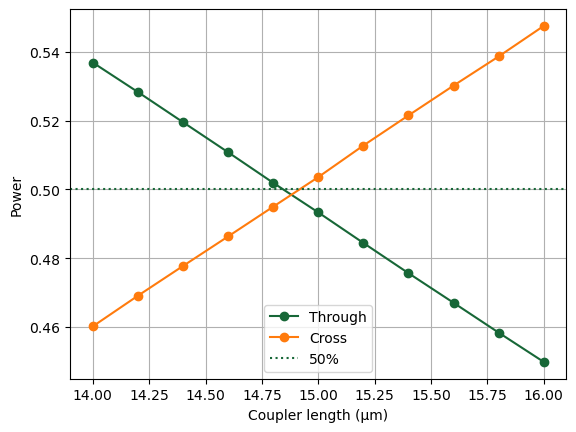

In [77]:
plt.plot(lengths, through, "o-", label="Through")
plt.plot(lengths, cross, "o-", label="Cross")
#plt.plot(lengths, total, "--", label="Total")

plt.axhline(0.5, linestyle=":", label="50%")
plt.xlabel("Coupler length (µm)")
plt.ylabel("Power")
plt.legend()
plt.grid()
plt.show()

based on this graph i can run some finer simulations. With smaller time steps and a narrower range

In [ ]:
lengths = np.linspace(14.8, 15, 5)

through = []
cross = []
total = []

mapping = {
    "si": medium_si_1550,
    "sio2": medium_sio2_1550,
}
simulation_settings = dict(
    run_only=(("o1", 0),),
    center_z="core",
    sim_size_z=1.9,
    medium=medium_sio2_1550,
    port_size_mult=(3, 2),
    wavelength=1.55,
    bandwidth=0,
    num_freqs=1,
    min_steps_per_wvl=30,
    run_time=3e-12,
)
component_settings = dict(
    layer_stack=LAYER_STACK,
    material_mapping=mapping,
    pad_xy_inner=0.8,
    pad_xy_outer=1,
    pad_z_inner=0,
    pad_z_outer=0,
    extend_ports=1.0,
)

for length in lengths:
    component = cells.coupler(gap=0.25, length=length)

    filepath = (Path.home()/ "tidy3d_results"/f"coupler_finer_L{length:.2f}.npz")

    sp = gt.write_sparameters(
        component=component,
        filepath=filepath,
        **component_settings,
        **simulation_settings,    
    )

    p_through = np.abs(sp["o1@0,o4@0"])**2
    p_cross = np.abs(sp["o1@0,o3@0"])**2

    through.append(p_through)
    cross.append(p_cross)
    total.append(p_through + p_cross)

18:02:29 CEST Created task 'c62f5982bd755577b4ce592d8dba4469' with resource_id  
              'sid-2bfeae9b-464c-4cdd-90b2-0477c0180cd5' and task_type          
              'MODAL_CM'.

Output()

18:02:39 CEST Maximum FlexCredit cost: 2.801. Minimum cost depends on task      
              execution details. Use 'web.real_cost(task_id)' after run.

18:02:40 CEST Subtasks status - c62f5982bd755577b4ce592d8dba4469                
              Group ID: 'pa-3fdcbfc8-911f-421b-9f87-11291a9a316b'

Output()

...

18:12:44 CEST Modeler has finished running successfully.

18:12:45 CEST Billed flex credit cost: 0.608.

Output()

18:12:48 CEST Loading results from                                              
              /Users/cadmus/.gdsfactory/sparameters/6aa9d23073c5ec86b30f0e5438ae
              68b8/simulation.hdf5

Simulation saved to PosixPath('/Users/cadmus/tidy3d_results/coupler_finer_L15.00.npz')


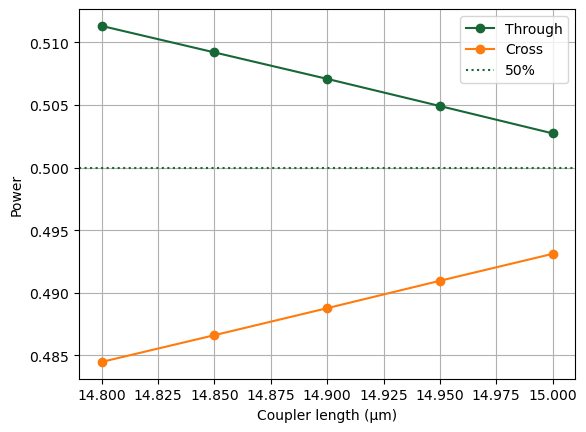

In [81]:
plt.plot(lengths, through, "o-", label="Through")
plt.plot(lengths, cross, "o-", label="Cross")
#plt.plot(lengths, total, "--", label="Total")

plt.axhline(0.5, linestyle=":", label="50%")
plt.xlabel("Coupler length (µm)")
plt.ylabel("Power")
plt.legend()
plt.grid()
plt.show()

with the finer simluations the coupling isn't quite 50/50. We move the range slightly:

In [ ]:
lengths = np.linspace(15, 15.2, 5)

through = []
cross = []
total = []

mapping = {
    "si": medium_si_1550,
    "sio2": medium_sio2_1550,
}
simulation_settings = dict(
    run_only=(("o1", 0),),
    center_z="core",
    sim_size_z=1.9,
    medium=medium_sio2_1550,
    port_size_mult=(3, 2),
    wavelength=1.55,
    bandwidth=0,
    num_freqs=1,
    min_steps_per_wvl=30,
    run_time=3e-12,
)
component_settings = dict(
    layer_stack=LAYER_STACK,
    material_mapping=mapping,
    pad_xy_inner=0.8,
    pad_xy_outer=1,
    pad_z_inner=0,
    pad_z_outer=0,
    extend_ports=1.0,
)

for length in lengths:
    component = cells.coupler(gap=0.25, length=length)

    filepath = (Path.home()/ "tidy3d_results"/f"coupler_finer_L{length:.2f}.npz")

    sp = gt.write_sparameters(
        component=component,
        filepath=filepath,
        **component_settings,
        **simulation_settings,    
    )

    p_through = np.abs(sp["o1@0,o4@0"])**2
    p_cross = np.abs(sp["o1@0,o3@0"])**2

    through.append(p_through)
    cross.append(p_cross)
    total.append(p_through + p_cross)

Simulation loaded from PosixPath('/Users/cadmus/tidy3d_results/coupler_finer_L15.00.npz')


18:18:44 CEST Created task '3d6b9f9337d7460f7a5010712c35583b' with resource_id  
              'sid-7f3be9fe-458f-4afe-a215-a527637b9b58' and task_type          
              'MODAL_CM'.

Output()

18:18:54 CEST Maximum FlexCredit cost: 2.819. Minimum cost depends on task      
              execution details. Use 'web.real_cost(task_id)' after run.

18:18:56 CEST Subtasks status - 3d6b9f9337d7460f7a5010712c35583b                
              Group ID: 'pa-b6044467-1b67-4f90-aa59-2c7f13b08222'

...

18:26:01 CEST Modeler has finished running successfully.

18:26:02 CEST Billed flex credit cost: 0.621.

Output()

18:26:05 CEST Loading results from                                              
              /Users/cadmus/.gdsfactory/sparameters/c671c92ade685737bacd856e1bd6
              f004/simulation.hdf5

Simulation saved to PosixPath('/Users/cadmus/tidy3d_results/coupler_finer_L15.20.npz')


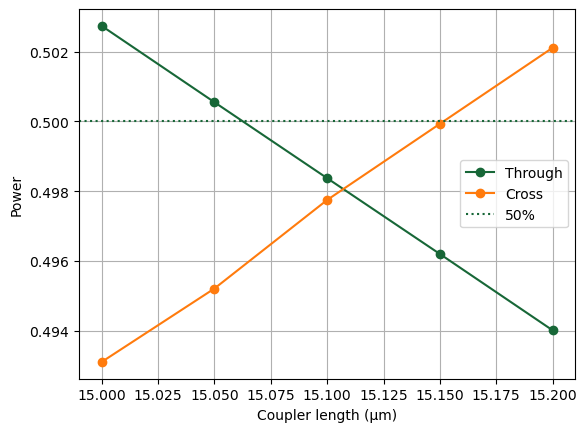

In [86]:
plt.plot(lengths, through, "o-", label="Through")
plt.plot(lengths, cross, "o-", label="Cross")
#plt.plot(lengths, total, "--", label="Total")

plt.axhline(0.5, linestyle=":", label="50%")
plt.xlabel("Coupler length (µm)")
plt.ylabel("Power")
plt.legend()
plt.grid()
plt.show()

for final convergence test

In [ ]:
lengths = np.linspace(15.05, 15.15, 3)

through = []
cross = []
total = []

mapping = {
    "si": medium_si_1550,
    "sio2": medium_sio2_1550,
}
simulation_settings = dict(
    run_only=(("o1", 0),),
    center_z="core",
    sim_size_z=1.9,
    medium=medium_sio2_1550,
    port_size_mult=(3, 2),
    wavelength=1.55,
    bandwidth=0,
    num_freqs=1,
    min_steps_per_wvl=35,
    run_time=3e-12,
)
component_settings = dict(
    layer_stack=LAYER_STACK,
    material_mapping=mapping,
    pad_xy_inner=0.8,
    pad_xy_outer=1,
    pad_z_inner=0,
    pad_z_outer=0,
    extend_ports=1.0,
)

for length in lengths:
    component = cells.coupler(gap=0.25, length=length)

    filepath = (Path.home()/ "tidy3d_results"/f"coupler_finer2_L{length:.2f}.npz")

    sp = gt.write_sparameters(
        component=component,
        filepath=filepath,
        **component_settings,
        **simulation_settings,    
    )

    p_through = np.abs(sp["o1@0,o4@0"])**2
    p_cross = np.abs(sp["o1@0,o3@0"])**2

    through.append(p_through)
    cross.append(p_cross)
    total.append(p_through + p_cross)

18:33:47 CEST Created task '46c9c4e6e84205f4dd018545468ae1e6' with resource_id  
              'sid-fb9df481-2643-41e0-ac19-106276611ac8' and task_type          
              'MODAL_CM'.

Output()

18:33:57 CEST Maximum FlexCredit cost: 4.852. Minimum cost depends on task      
              execution details. Use 'web.real_cost(task_id)' after run.

18:33:59 CEST Subtasks status - 46c9c4e6e84205f4dd018545468ae1e6                
              Group ID: 'pa-0b81ef8d-8365-480d-88c9-deedca6db951'

Output()

...

18:40:29 CEST Modeler has finished running successfully.

18:40:31 CEST Billed flex credit cost: 1.042.

Output()

18:40:34 CEST Loading results from                                              
              /Users/cadmus/.gdsfactory/sparameters/4f023b3c473e56b38f25ce9964ed
              a8e1/simulation.hdf5

Simulation saved to PosixPath('/Users/cadmus/tidy3d_results/coupler_finer2_L15.15.npz')


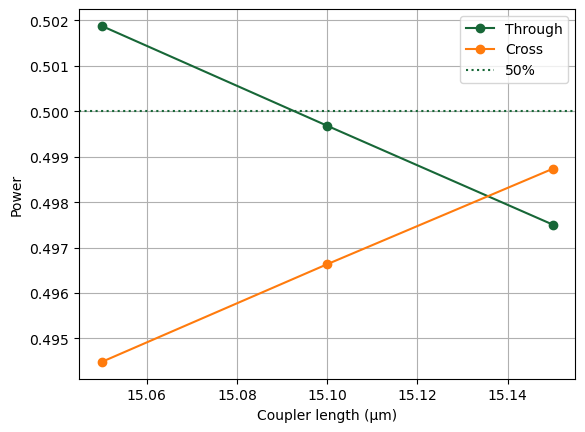

In [90]:
plt.plot(lengths, through, "o-", label="Through")
plt.plot(lengths, cross, "o-", label="Cross")
#plt.plot(lengths, total, "--", label="Total")

plt.axhline(0.5, linestyle=":", label="50%")
plt.xlabel("Coupler length (µm)")
plt.ylabel("Power")
plt.legend()
plt.grid()
plt.show()

The iterations are concluded with the optimum length found to be 15.135 $\mu m$. Realisticaly fabrication tolerances are greater than this level of accuracy, but it is a useful baseline. For final results I run the simulation at the optimum length.

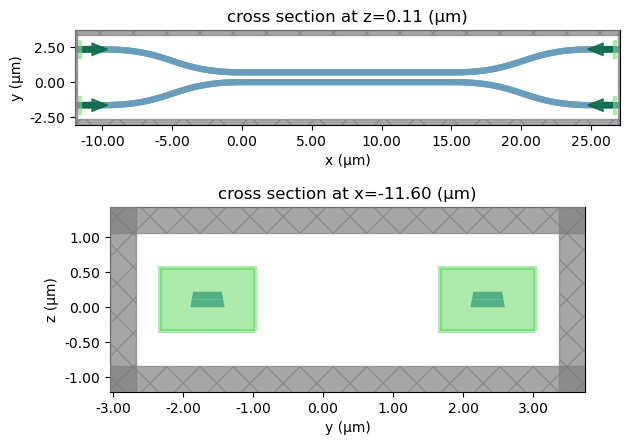

In [ ]:
component=cells.coupler(gap=0.25, length=15.135)

mapping = {
    "si": medium_si_1550,
    "sio2": medium_sio2_1550,
}

component_settings = dict(
    layer_stack=LAYER_STACK,
    material_mapping=mapping,
    pad_xy_inner=0.8,
    pad_xy_outer=1,
    pad_z_inner=0,
    pad_z_outer=0,
    extend_ports=1.0,
)

simulation_settings = dict(
    run_only=(("o1", 0),("o2", 0),),
    center_z="core",
    sim_size_z=1.9,
    medium=medium_sio2_1550,
    port_size_mult=(3, 2),
    wavelength=1.55,
    bandwidth=0,
    num_freqs=1,
    min_steps_per_wvl=35,
    run_time=3e-12,
)

td_component = gt.Tidy3DComponent(
    component=component,
    **component_settings,
)

modeler = td_component.get_component_modeler(
    **simulation_settings,
)

fig, ax = plt.subplots(2, 1)
modeler.plot_sim(z=td_component.get_layer_center("core")[2], ax=ax[0])
modeler.plot_sim(x=td_component.ports[0].dcenter[0], ax=ax[1])
fig.tight_layout()
plt.show()

In [23]:
filepath = (Path.home() / "tidy3d_results" / "coupler2_3d_gap0.25_2port.npz")
filepath.parent.mkdir(parents=True, exist_ok=True)

sp = gt.write_sparameters(
    component=component,
    filepath=filepath,
    **component_settings,
    **simulation_settings,
)

10:54:23 CEST Created task '18831a527eab7a08ca0a887b9e902442' with resource_id  
              'sid-b8758141-5268-44d0-a404-85673086aadb' and task_type          
              'MODAL_CM'.

Output()

10:54:33 CEST Maximum FlexCredit cost: 9.726. Minimum cost depends on task      
              execution details. Use 'web.real_cost(task_id)' after run.

10:54:34 CEST Subtasks status - 18831a527eab7a08ca0a887b9e902442                
              Group ID: 'pa-f5dd6e91-8186-4400-b74d-c35e28a0f966'

Output()

...

10:56:35 CEST Modeler has finished running successfully.

10:56:36 CEST Billed flex credit cost: 2.084.

Output()

10:56:38 CEST Loading results from                                              
              /Users/cadmus/.gdsfactory/sparameters/18831a527eab7a08ca0a887b9e90
              2442/simulation.hdf5

Simulation saved to PosixPath('/Users/cadmus/tidy3d_results/coupler2_3d_gap0.25_2port.npz')


In [24]:
through1 = np.abs(sp["o1@0,o4@0"])**2
cross1   = np.abs(sp["o1@0,o3@0"])**2
through2 = np.abs(sp["o2@0,o3@0"])**2
cross2   = np.abs(sp["o2@0,o4@0"])**2

print("Through1 power:", through1, "phase =", np.angle(sp['o1@0,o4@0'], deg=True))
print("Cross1 power:", cross1, 'phase=', np.angle(sp['o1@0,o3@0'], deg=True))
print("Total:", through1 + cross1)
print("Through2 power:", through2, "phase =", np.angle(sp['o2@0,o3@0'], deg=True))
print("Cross2 power:", cross2, 'phase=', np.angle(sp['o2@0,o4@0'], deg=True))
print("Total:", through2 + cross2)

Through1 power: [0.49809398] phase = [-27.21568985]
Cross1 power: [0.49816045] phase= [59.63378517]
Total: [0.99625443]
Through2 power: [0.49808393] phase = [-36.30837369]
Cross2 power: [0.49814179] phase= [56.83547762]
Total: [0.99622573]


In [28]:
c = sp["o1@0,o3@0"]/A
d = sp["o1@0,o4@0"]/A
delta = np.angle(c / d)
print(np.degrees(delta))
c2 = sp["o2@0,o4@0"]/A
d2 = sp["o2@0,o3@0"]/A
delta2 = np.angle(c2 / d2)
print(np.degrees(delta2))
print(np.degrees(delta)+np.degrees(delta2))

[86.84947502]
[93.14385132]
[179.99332634]


As we can see from the two port simulation the phase differences add up to $86.85^\circ + 93.14^\circ = 179.99^\circ$. So the phase of the simulation is physically consistent with a real coupler. Therefore the sax model will use the two port simulation. Using a one port simulation and using a symmetry argument is not physically correct because the individual cross through phase difference is not exactly 90degrees. But the two port simulation is correct. Explained further in main notebook. This coupelr has loss bit it has a nearly ideal unitary transformation

###### ------------------------------------------------------------------------------------------------
### Calibrating & Saving as Sax model
This S matrix result is calibrated for the phase offset explained in [Phase Calibration](#phase-calibration) and converted to a sax format dictionary and saved in a folder sax_models. Other scripts can load this Smatrix immediately from the file for Sax simulations.

In [29]:

coupler_dict=sax.reciprocal({
    ("in0", "out0"): d,
    ("in0", "out1"): c,
    ("in1", "out0"): c2,
    ("in1", "out1"): d2
})
print(type(coupler_dict))

filepath = Path.home() / "sax_models" / "coupler_50_50_2port.pkl"
filepath.parent.mkdir(parents=True, exist_ok=True)

with filepath.open("wb") as f:
    pickle.dump(coupler_dict, f)


<class 'dict'>


In [30]:
with filepath.open("rb") as f:
    sax_sdict = pickle.load(f)
print(sax_sdict)

{('in0', 'out0'): array([0.66587351+0.23389409j]), ('in0', 'out1'): array([-0.19695776+0.67776699j]), ('in1', 'out0'): array([-0.16363107+0.68656148j]), ('in1', 'out1'): array([0.69446189+0.12572439j]), ('out0', 'in0'): array([0.66587351+0.23389409j]), ('out1', 'in0'): array([-0.19695776+0.67776699j]), ('out0', 'in1'): array([-0.16363107+0.68656148j]), ('out1', 'in1'): array([0.69446189+0.12572439j])}


Note at the output the phases differ by $\pm \pi/2$ and this is indeed true here

## S bend
Here we find the S matrix of the Sbend I use in the project. The bend geometry is defined in the file my_components.py, it is plotted below

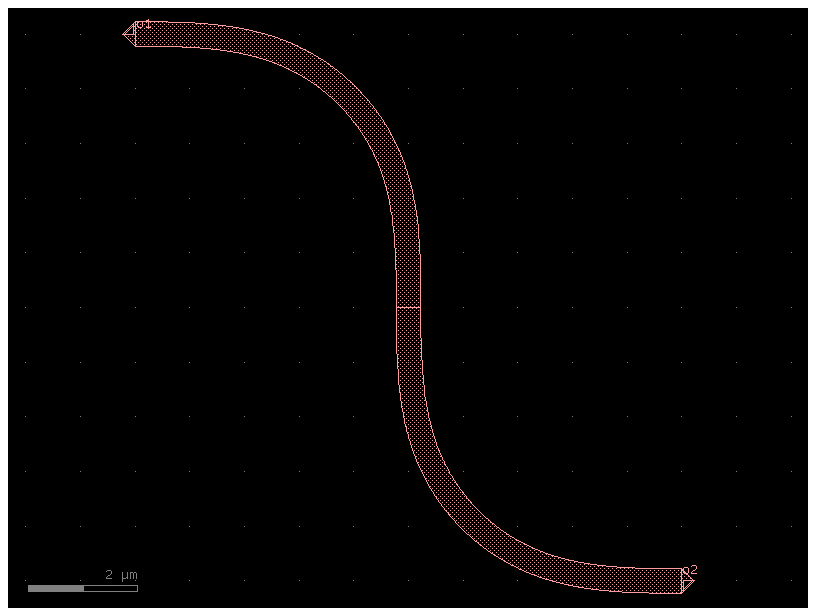

In [24]:
bend = my.s_bend()
bend.draw_ports()
bend.plot()

This component does not need optimization, hence we can immediately run a high resolution fdtd simulation

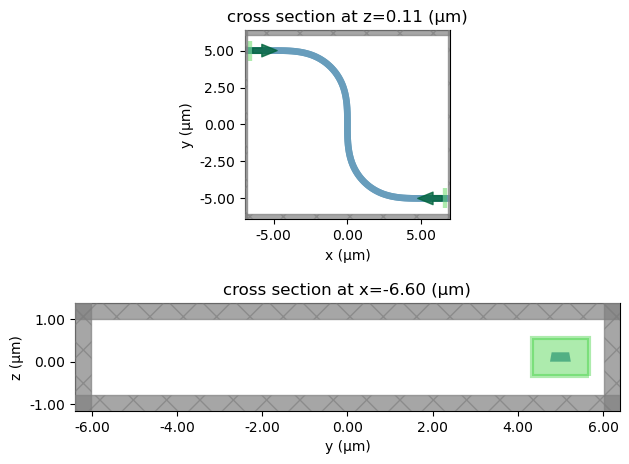

In [ ]:
mapping = {
    "si": medium_si_1550,
    "sio2": medium_sio2_1550,
}

component_settings = dict(
    layer_stack=LAYER_STACK,
    material_mapping=mapping,
    pad_xy_inner=0.8,
    pad_xy_outer=1,
    pad_z_inner=0,
    pad_z_outer=0,
    extend_ports=1.0,
)

simulation_settings = dict(
    run_only=(("o1", 0),),
    center_z="core",
    sim_size_z=1.8,
    medium=medium_sio2_1550,
    port_size_mult=(3, 2),
    wavelength=1.55,
    bandwidth=0,
    num_freqs=1,
    min_steps_per_wvl=35,
    run_time=3e-12,
)

td_component = gt.Tidy3DComponent(
    component=bend,
    **component_settings,
)

modeler = td_component.get_component_modeler(
    **simulation_settings,
)


fig, ax = plt.subplots(2, 1)
modeler.plot_sim(z=td_component.get_layer_center("core")[2], ax=ax[0])
modeler.plot_sim(x=td_component.ports[0].dcenter[0], ax=ax[1])
fig.tight_layout()
plt.show()

In [30]:
filepath = (Path.home() / "tidy3d_results" / "s_bend.npz")
filepath.parent.mkdir(parents=True, exist_ok=True)

sp_bend = gt.write_sparameters(
    component=bend,
    filepath=filepath,
    **component_settings,
    **simulation_settings,
)

Simulation loaded from PosixPath('/Users/cadmus/tidy3d_results/s_bend.npz')


In [35]:
power = np.abs(sp_bend["o1@0,o2@0"])**2

print("Through power:", power, "phase =", np.angle(sp_bend['o1@0,o2@0']/A, deg=True))

Through power: [0.99787486] phase = [116.1029383]


In [36]:
bend_dict=sax.reciprocal({
    ("in0", "out0"): sp_bend["o1@0,o2@0"]/A
})

filepath = Path.home() / "sax_models" / "s_bend.pkl"
filepath.parent.mkdir(parents=True, exist_ok=True)

with filepath.open("wb") as f:
    pickle.dump(bend_dict, f)


In [37]:
with filepath.open("rb") as f:
    sax_sdict = pickle.load(f)
print(sax_sdict)

{('in0', 'out0'): array([-0.43951746+0.89705031j]), ('out0', 'in0'): array([-0.43951746+0.89705031j])}


## Phase Shifter & Straight Waveguide

For the phase shifter we use the thermooptic phase shifter straight_metal_heater from the Cornerstone pdk. This is a TiN heater above the standard Si waveguide.

The pdk phase shifter from cornerstone is based on the paper [Link](https://opg.optica.org/oe/fulltext.cfm?uri=oe-27-8-10456). Based on that paper we also use the following theoretical framework to optimize the phase shifter. 

The temperature dependant phase change is given by $\Delta \Phi = \frac{2\pi L}{\lambda_0}\frac{dn}{dT}\Delta T$

Where L is the length of the waveguide, $\Delta T$ is the tempereature change and $\frac{dn}{dT}$ is the thermooptic coefficient. \
Thermooptic coefficient of Silicon $\frac{dn}{dT}=1.8\times 10^{-4}K^{-1}$ at T=300K, $\lambda_0  = 1550nm$

Then for a phase shift of $\pi$ the temperature change required is given by $\Delta T_{\pi} = \frac{\lambda_0}{2L\frac{dn}{dT}}$ \
based on this we construct the following graph for $\lambda_0=1.55\mu m$

Text(0, 0.5, 'Temperature Change for Pi phase shift')

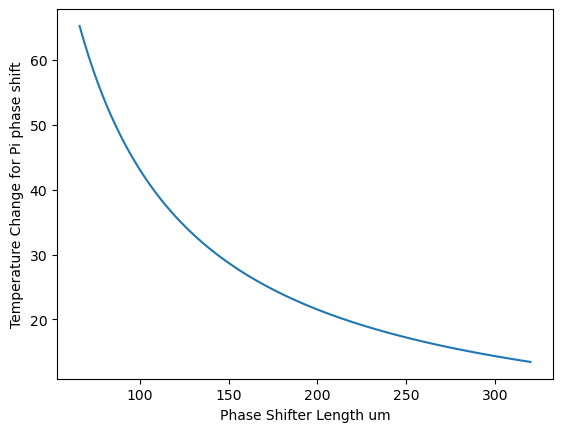

In [31]:
lens=np.linspace(66,320,100)
plt.plot(lens, T_pi(lens))
plt.xlabel("Phase Shifter Length um")
plt.ylabel("Temperature Change for Pi phase shift")

Practically there are many factors that constrain the maximum temperature change that can occur in the waveguide, including but not limited to the metal heater votage and power, operating temperature, stability of chip structure (all the different layers), changing optical behaviours such as absoprtion etc. I do not have any data on these and it needs to be determined by characterising a real chip. Theoretical FEM models are a useful baseline but practical factors have big impact. To choose a maximum temperature range I take a conservative estimate of 30K. Based on the graph this requires a phase shifter with length greater than $150 \mu m$. I will thus select a phase shifter with length $150\mu m$. This corresponds to a temperature change of $28^\circ$ for a $\pi$ phase shift.

In terms of the power, the paper [Link](https://opg.optica.org/oe/fulltext.cfm?uri=oe-27-8-10456), shows that the thermal power required for the $\pi$ phase shift $P_{\pi}$ is independent of the length of the resistor and waveguide. For the TiN heater in the pdk this power is $P_{\pi}=23.9mW$. Considering an ideal heater and the linearity of the thermooptic effect we can plot the phase difference response to the supplied electrical power.

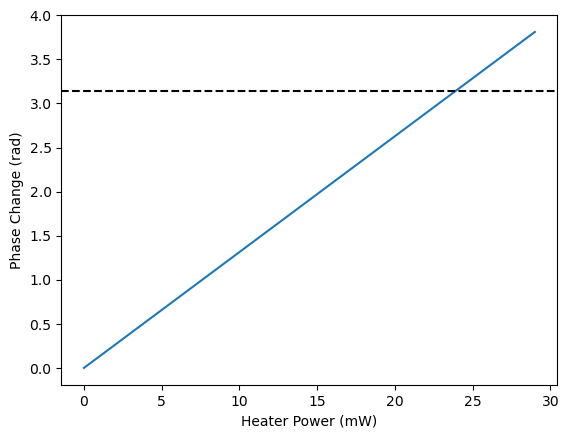

In [45]:
Power=np.arange(30)
plt.plot(Power, Power*np.pi/23.9)
plt.xlabel("Heater Power (mW)")
plt.ylabel("Phase Change (rad)")
plt.axhline(y=np.pi, linestyle="--",color='k')

Now that we have defined a length for the phase shifter ($150\mu m$) and the phase-power response we can construct S-matrices. There are two steps to this, first to find the optical phase accumulation from the waveguide without the thermooptic effect. Next is to define a function that adds the thermooptic phase shift to the waveguide response and returns an Smatrix.

The phase shifter waveguide is the standard cross section of the pdk, the same as that of cells.straight()

A length of $150\mu m$ is quite large for an fdtd simulation, and the waveguide has one profilee so we can calculate the phase by considering a shorter waveguide of length $10\mu m$ and propagating it 15 times to achieve a length of $150\mu m$.

In [45]:
sp1 = np.load(Path.home()/ "tidy3d_results"/"straight_45_L10.00.npz")
cal_1 = sp1["o1@0,o2@0"]/A
cal_150 = cal_1**15
print(cal_150)
print(abs(cal_150)**2)

[-0.34962881+0.91173747j]
[0.95350552]


Now we have the phase accumulated over the length of $150\mu m$ and the power coefficient of 0.95. For the purpose of the interferrometer mesh,the phase at the end of the waveguide is necessary, but the power loss is not. The fdtd simulations also use a lossless material so the power estimates are all unecessary. For this reason I construct the waveguide Smatrix with the correct numerical phase, but I will make the transmission coefficient 1.

The following saves the Smatrix for a waveguide of length $150\mu m$.

The phase shifter of the same lengths requires an additional thermooptic term as shown in the next section


In [51]:
waveguide_trans = 1*np.exp(1j*np.angle(cal_150))

waveguide_150_dict=sax.reciprocal({
    ("in0", "out0"): waveguide_trans
})

filepath = Path.home() / "sax_models" / "waveguide_150.pkl"
filepath.parent.mkdir(parents=True, exist_ok=True)

with filepath.open("wb") as f:
    pickle.dump(waveguide_150_dict, f)

In [13]:
filepath = Path.home() / "sax_models" / "waveguide_150.pkl"
filepath.parent.mkdir(parents=True, exist_ok=True)
with filepath.open("rb") as f:
    sax_sdict = pickle.load(f)
print(sax_sdict[('in0','out0')])
print(np.angle(sax_sdict[('in0','out0')]))
print(abs(sax_sdict[('in0','out0')]))

[-0.35805159+0.9337018j]
[1.93697663]
[1.]


### Phase shifter function

Ultimately the copmlete circuit simulations should simulate the response of these realistic components. The phas of the phaseshifters should be tunable ,this is the key part. SO the Smatrix of the phase shifter should be a function that takes input phase and outputs S matrix and thermal data.
question is phase shift of pi enough or do i need 2pi

So we have a phase shifter with $T_{\pi}=28 ^\circ$ and $P_{\pi}=23.9mW$ so $P_{2\pi}=47.8$. We thus define a function phaser() that returns the Sax Smatrix for the desired phase, and a functions phaser_power() which returns the corresponding power required to produce the phase shift.

The mesh phaseshifts that are returns by the phaseshift library (check main notebook) are extra phase shifts relative to other paths. This means that the phase shifter total phase should be the phase accumulatd by the normal waveguide plus the extra additional required phase produced by the thermooptic heater.

The following functions are defined in mylibrary for importing into project file

In [ ]:
'''
phi must be in radians
default wavegudie is the 150um waveguide
returns sax matrix of phase with total phase= standard waveguide phase + added thermooptic phase
'''

def phaser_matrix(phi, waveguide='waveguide_150.pkl'):
    filepath = Path.home() / "sax_models" / waveguide
    with filepath.open("rb") as f:
        ref_sdict = pickle.load(f)
    ref_phase = np.angle(ref_sdict[('in0','out0')])
    new = np.exp(1j*(ref_phase+phi))
    new_dict = sax.reciprocal({("in0", "out0"): new})
    return new_dict
    

In [25]:
'''
phi must be in radians
returns power in mW
'''
def phaser_power(phi):
    return phi*23.9/np.pi

## Coupler Single Arm

The project also uses a component named coupler_single_arm. This is one arm of the pdk coupler. This component is used so the final mesh preserves path lengths across different paths. The following is the simualtion of this component and Smattrix generation.

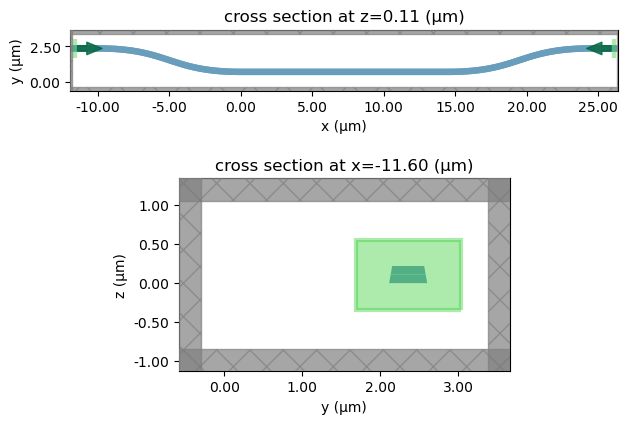

In [ ]:
single_arm = my.coupler_single_arm()
mapping = {
    "si": medium_si_1550,
    "sio2": medium_sio2_1550,
}

component_settings = dict(
    layer_stack=LAYER_STACK,
    material_mapping=mapping,
    pad_xy_inner=0.8,
    pad_xy_outer=1,
    pad_z_inner=0,
    pad_z_outer=0,
    extend_ports=1.0,
)

simulation_settings = dict(
    run_only=(("o1", 0),),
    center_z="core",
    sim_size_z=1.9,
    medium=medium_sio2_1550,
    port_size_mult=(3, 2),
    wavelength=1.55,
    bandwidth=0,
    num_freqs=1,
    min_steps_per_wvl=45,
    run_time=3e-12,
)

td_component = gt.Tidy3DComponent(
    component=single_arm,
    **component_settings,
)

modeler = td_component.get_component_modeler(
    **simulation_settings,
)


fig, ax = plt.subplots(2, 1)
modeler.plot_sim(z=td_component.get_layer_center("core")[2], ax=ax[0])
modeler.plot_sim(x=td_component.ports[0].dcenter[0], ax=ax[1])
fig.tight_layout()
plt.show()


In [22]:
filepath = (Path.home() / "tidy3d_results" / "single_arm.npz")
filepath.parent.mkdir(parents=True, exist_ok=True)

sp_arm = gt.write_sparameters(
    component=single_arm,
    filepath=filepath,
    **component_settings,
    **simulation_settings,
)

Simulation loaded from PosixPath('/Users/cadmus/tidy3d_results/single_arm.npz')


In [36]:
power = np.abs(sp_arm["o1@0,o2@0"])**2

print("Through power:", power, "phase =", np.angle(sp_bend['o1@0,o2@0']/A))

Through power: [0.99612539] phase = [0.49184859]


In [32]:
arm_dict=sax.reciprocal({
    ("in0", "out0"): sp_arm["o1@0,o2@0"]/A
})

filepath = Path.home() / "sax_models" / "s_arm.pkl"
filepath.parent.mkdir(parents=True, exist_ok=True)

with filepath.open("wb") as f:
    pickle.dump(arm_dict, f)

In [35]:
with filepath.open("rb") as f:
    sax_sdict = pickle.load(f)
print(sax_sdict)
print(np.angle(sax_sdict[('in0','out0')]))
print(abs(sax_sdict[('in0','out0')]))

{('in0', 'out0'): array([0.87975204+0.47134036j]), ('out0', 'in0'): array([0.87975204+0.47134036j])}
[0.49184859]
[0.99806082]
